# Demonstration of MUSE

This is a demonstration of MUSE analysis on a multi-modality simulated data.

Feng Bao @ Altschuler & Wu Lab @ UCSF 2022.

Software provided as is under MIT License.

## Import packages

In [22]:
import multi_muse_sc as muse
import simulation_tool.multi_modal_simulation as simulation

import phenograph
from sklearn.decomposition import PCA
import numpy as np
from sklearn.metrics.cluster import adjusted_rand_score
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
np.random.seed(0)

## Generate simulation data


Simulation parameters

In [23]:
latent_dim = 100
num_cluster = 10
sample_size = 1000
latent_code_dim = 30
observed_data_dim = 500
sigma_1 = 0.1  
sigma_2 = 0.1
decay_coef_1 = 0.5 
decay_coef_2 = 0.1
merge_prob = 0.7



Use simulation tool to generate multi-modality data

In [24]:
data = simulation.multi_modal_simulator(
    num_cluster,
    sample_size,
    observed_data_dim,
    observed_data_dim,
    latent_code_dim,
    sigma_1,
    sigma_2,
    decay_coef_1,
    decay_coef_2,
    merge_prob,
)
data_a = data["data_a_dropout"]
data_b = data["data_b_dropout"]
label_a = data["data_a_label"]
label_b = data["data_b_label"]
label_true = data["true_cluster"]

## Analyses based on single modality

Learn features from single modality

In [25]:
data_ab = data_a + data_b

view_a_feature = PCA(n_components=latent_dim, random_state=42).fit_transform(data_a)
view_b_feature = PCA(n_components=latent_dim, random_state=42).fit_transform(data_b)
view_ab_feature = PCA(n_components=latent_dim, random_state=42).fit_transform(data_ab)

In [26]:
print(f"data_a shape: {data_a.shape}")
print(f"data_b shape: {data_b.shape}")
print(f"view_a_feature shape: {view_a_feature.shape}")
print(f"view_b_feature shape: {view_b_feature.shape}")

data_a shape: (1000, 500)
data_b shape: (1000, 500)
view_a_feature shape: (1000, 100)
view_b_feature shape: (1000, 100)


Perform clustering using PhenoGraph

In [27]:
view_a_label, _, _ = phenograph.cluster(view_a_feature, random_state=42)
view_b_label, _, _ = phenograph.cluster(view_b_feature, random_state=42)
view_ab_label, _, _ = phenograph.cluster(view_ab_feature, random_state=42)

Finding 30 nearest neighbors using minkowski metric and 'auto' algorithm
Neighbors computed in 0.03694558143615723 seconds


Jaccard graph constructed in 0.45156192779541016 seconds
Wrote graph to binary file in 0.005337238311767578 seconds
Running Louvain modularity optimization
After 1 runs, maximum modularity is Q = 0.496473
Louvain completed 21 runs in 0.9993247985839844 seconds
Sorting communities by size, please wait ...
PhenoGraph completed in 1.9783787727355957 seconds
Finding 30 nearest neighbors using minkowski metric and 'auto' algorithm
Neighbors computed in 0.06890487670898438 seconds
Jaccard graph constructed in 0.4224581718444824 seconds
Wrote graph to binary file in 0.004592180252075195 seconds
Running Louvain modularity optimization
After 1 runs, maximum modularity is Q = 0.723724
Louvain completed 21 runs in 1.002920150756836 seconds
Sorting communities by size, please wait ...
PhenoGraph completed in 1.9070208072662354 seconds
Finding 30 nearest neighbors using minkowski metric and 'auto' algorithm
Neighbors computed in 0.06928157806396484 seconds
Jaccard graph constructed in 0.47842621803

## Combined analysis using MUSE

MUSE learns the joint latent representation

In [28]:
X_embedded = TSNE(n_components=2, random_state=42).fit_transform(view_a_feature)
Y_embedded = TSNE(n_components=2, random_state=42).fit_transform(view_b_feature)
XY_embedded = TSNE(n_components=2, random_state=42).fit_transform(view_ab_feature)

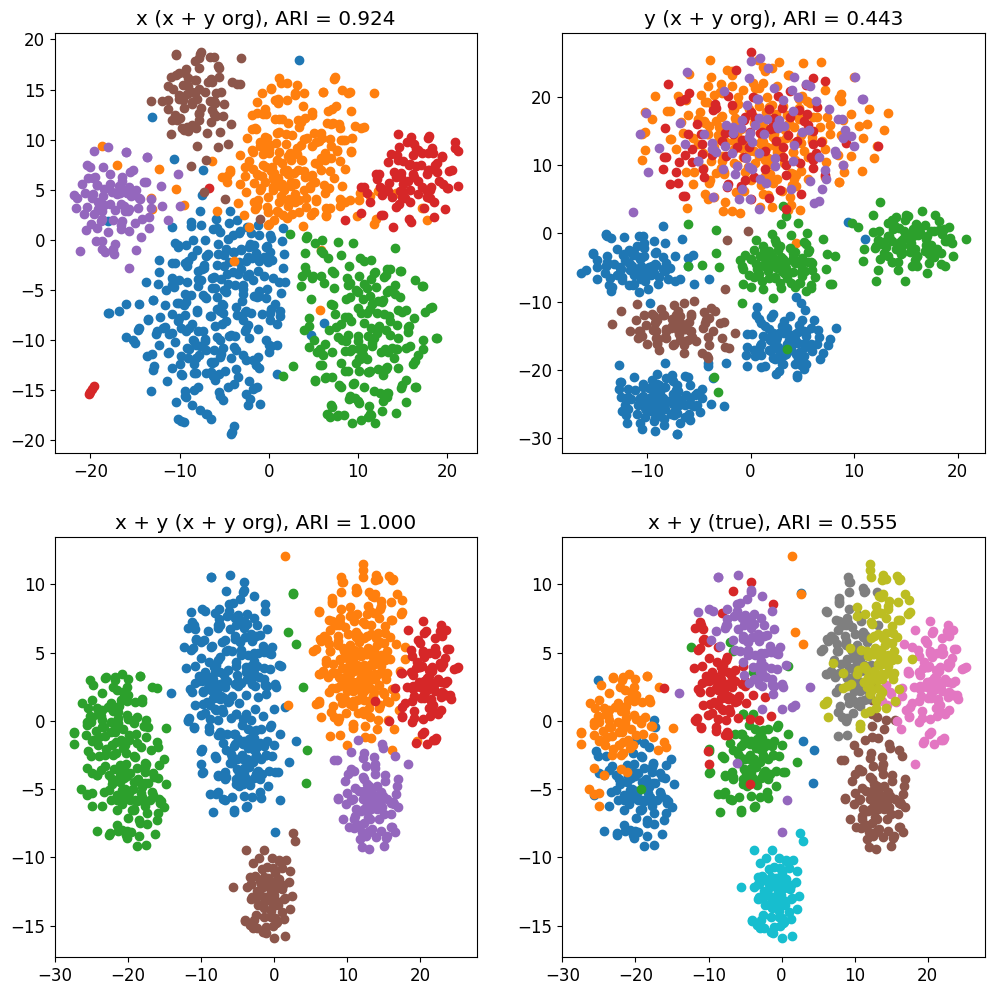

In [29]:
plt.rcParams['font.size'] = 12
plt.figure(figsize=(12, 12))
plt.subplot(2, 2, 1)
# 遍历每一个类别
for i in np.unique(view_ab_label):
    # 找到所有类别为i的索引
    idx = np.nonzero(view_ab_label == i)[0]
    # 将类别为i的点画成散点图
    plt.scatter(X_embedded[idx, 0], X_embedded[idx, 1])
    # 设置标题
    plt.title('x (x + y org), ARI = %01.3f' % adjusted_rand_score(view_ab_label, view_a_label))

plt.subplot(2, 2, 2)
for i in np.unique(view_ab_label):
    idx = np.nonzero(view_ab_label == i)[0]
    plt.scatter(Y_embedded[idx, 0], Y_embedded[idx, 1])
    plt.title('y (x + y org), ARI = %01.3f' % adjusted_rand_score(view_ab_label, view_b_label))

plt.subplot(2, 2, 3)
for i in np.unique(view_ab_label):
    idx = np.nonzero(view_ab_label == i)[0]
    plt.scatter(XY_embedded[idx, 0], XY_embedded[idx, 1])
    plt.title('x + y (x + y org), ARI = %01.3f' % adjusted_rand_score(view_ab_label, view_ab_label))

plt.subplot(2, 2, 4)
for i in np.unique(label_true):
    idx = np.nonzero(label_true == i)[0]
    plt.scatter(XY_embedded[idx, 0], XY_embedded[idx, 1])
    plt.title('x + y (true), ARI = %01.3f' % adjusted_rand_score(view_ab_label, label_true))
plt.show()

In [43]:
outputs = muse.dual_muse_fit_predict(
    [data_a],
    [data_b],
    [view_a_label],
    [view_b_label],
    latent_dim=100,
    n_hidden=128,
    n_epochs=500,
    info_nce_lambda=100,
    weight_penalty=1,
    triplet_lambda=5,
    info_nce_lambda_sc=0,
    info_nce_lambda_st=0,
)

++++++++++ DualMUSE for multi-modality single-cell analysis ++++++++++
#epoch: 0/200 	 total loss: 1592.45 	 sc loss: 106.63 	 st loss: 112.69 	 infoNCE: 1373.13 	 sc recon: 7.07 	 st recon: 12.72 	 sc sparse: 99.57 	 st sparse: 99.97 	 sc trip: 0.00 	 st trip: 0.00 	 sc infoNCE: 0.00 	 st infoNCE: 0.00
#epoch: 25/200 	 total loss: 579.90 	 sc loss: 102.70 	 st loss: 102.54 	 infoNCE: 374.66 	 sc recon: 6.08 	 st recon: 5.38 	 sc sparse: 96.62 	 st sparse: 97.16 	 sc trip: 0.00 	 st trip: 0.00 	 sc infoNCE: 0.00 	 st infoNCE: 0.00
#epoch: 50/200 	 total loss: 389.67 	 sc loss: 99.63 	 st loss: 99.22 	 infoNCE: 190.81 	 sc recon: 5.90 	 st recon: 4.86 	 sc sparse: 93.73 	 st sparse: 94.37 	 sc trip: 0.00 	 st trip: 0.00 	 sc infoNCE: 0.00 	 st infoNCE: 0.00
#epoch: 75/200 	 total loss: 319.20 	 sc loss: 96.70 	 st loss: 96.29 	 infoNCE: 126.22 	 sc recon: 5.79 	 st recon: 4.70 	 sc sparse: 90.91 	 st sparse: 91.59 	 sc trip: 0.00 	 st trip: 0.00 	 sc infoNCE: 0.00 	 st infoNCE: 0.00
#ep

## Perform clustering
PhenoGraph clustering

In [44]:
latent_sc, latent_st = outputs[0], outputs[1]
muse_label_sc, _, _ = phenograph.cluster(latent_sc, random_state=42)
muse_label_st, _, _ = phenograph.cluster(latent_st, random_state=42)
# 用kmeans聚类
from sklearn.cluster import KMeans
n_clusters = np.unique(view_ab_label).shape[0]
print(f"n_clusters: {n_clusters}")
kmeans_sc = KMeans(n_clusters=n_clusters).fit_predict(latent_sc)
kmeans_st = KMeans(n_clusters=n_clusters).fit_predict(latent_st)


Finding 30 nearest neighbors using minkowski metric and 'auto' algorithm
Neighbors computed in 0.06849050521850586 seconds
Jaccard graph constructed in 0.4431021213531494 seconds
Wrote graph to binary file in 0.0044765472412109375 seconds
Running Louvain modularity optimization
After 1 runs, maximum modularity is Q = 0.513718
Louvain completed 21 runs in 1.0035574436187744 seconds
Sorting communities by size, please wait ...
PhenoGraph completed in 1.9481804370880127 seconds
Finding 30 nearest neighbors using minkowski metric and 'auto' algorithm
Neighbors computed in 0.06743359565734863 seconds
Jaccard graph constructed in 0.5075230598449707 seconds
Wrote graph to binary file in 0.004076957702636719 seconds
Running Louvain modularity optimization
After 1 runs, maximum modularity is Q = 0.471378
After 2 runs, maximum modularity is Q = 0.472564
Louvain completed 22 runs in 1.249455451965332 seconds
Sorting communities by size, please wait ...
PhenoGraph completed in 2.2749581336975098 s

In [45]:
reconstruct_sc = (outputs[2])
reconstruct_st = (outputs[3])
encoded_sc = (outputs[4])
encoded_st = (outputs[5])
print(f"latent_sc: {latent_sc.shape}")
print(f"latent_st: {latent_st.shape}")
print(f"reconstruct_sc: {len(reconstruct_sc)}")
print(f"reconstruct_st: {len(reconstruct_st)}")
print(f"encoded_sc: {encoded_sc.shape}")
print(f"encoded_st: {encoded_st.shape}")

latent_sc: (1000, 100)
latent_st: (1000, 100)
reconstruct_sc: 1
reconstruct_st: 1
encoded_sc: (1, 1000, 128)
encoded_st: (1, 1000, 128)


## Visualization of latent spaces 
Latent spaces of single-modality features or MUSE features were visualized using tSNE, with ground truth cluster labels.

Cluster accuries were quantified using adjusted Rand index (ARI). ARI = 1 indicates perfectly discover true cell identities.

In [46]:
X_embedded = TSNE(n_components=2, random_state=42).fit_transform(latent_sc)
Y_embedded = TSNE(n_components=2, random_state=42).fit_transform(latent_st)

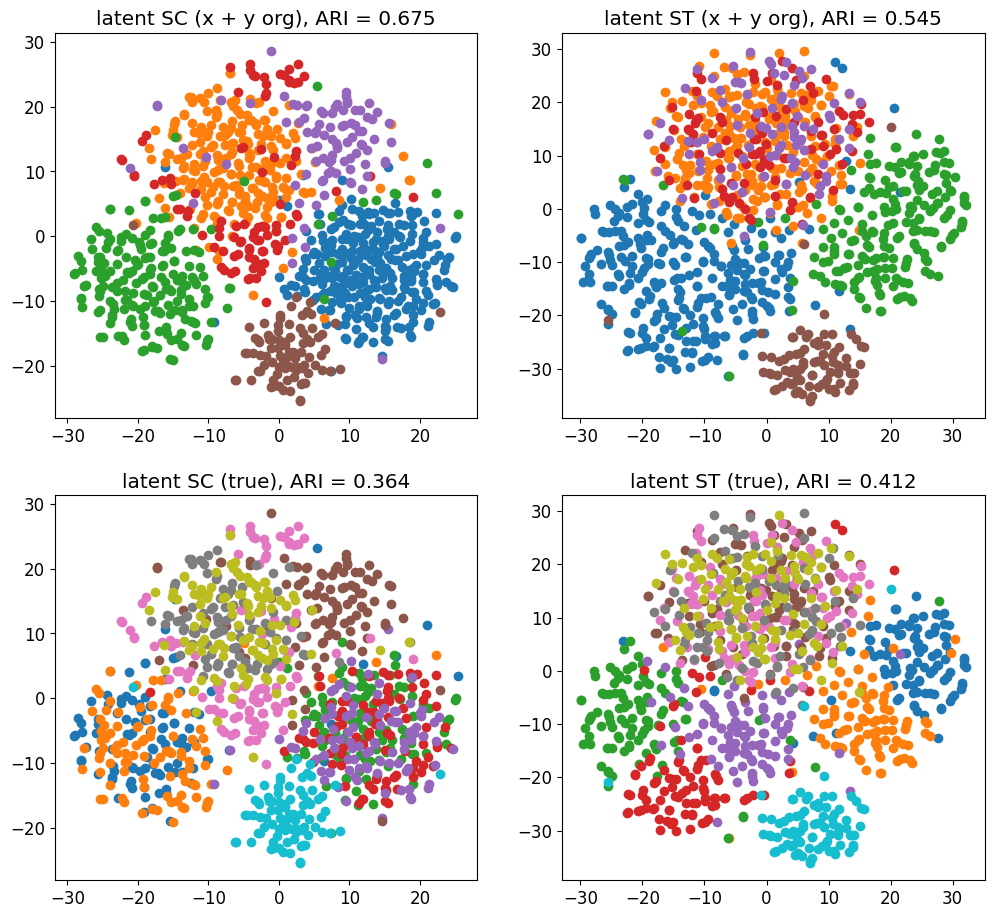

In [47]:
plt.figure(figsize=(12, 11))
plt.subplot(2, 2, 1)
for i in np.unique(view_ab_label):
    idx = np.nonzero(view_ab_label == i)[0]
    plt.scatter(X_embedded[idx, 0], X_embedded[idx, 1])
    plt.title('latent SC (x + y org), ARI = %01.3f' % adjusted_rand_score(view_ab_label, muse_label_sc))

plt.subplot(2, 2, 2)
for i in np.unique(view_ab_label):
    idx = np.nonzero(view_ab_label == i)[0]
    plt.scatter(Y_embedded[idx, 0], Y_embedded[idx, 1])
    plt.title('latent ST (x + y org), ARI = %01.3f' % adjusted_rand_score(view_ab_label, muse_label_st))

plt.subplot(2, 2, 3)
for i in np.unique(label_true):
    idx = np.nonzero(label_true == i)[0]
    plt.scatter(X_embedded[idx, 0], X_embedded[idx, 1])
    plt.title('latent SC (true), ARI = %01.3f' % adjusted_rand_score(label_true, muse_label_sc))

plt.subplot(2, 2, 4)
for i in np.unique(label_true):
    idx = np.nonzero(label_true == i)[0]
    plt.scatter(Y_embedded[idx, 0], Y_embedded[idx, 1])
    plt.title('latent ST (true), ARI = %01.3f' % adjusted_rand_score(label_true, muse_label_st))

In [48]:
print('phenograph SC and ST ARI: ', adjusted_rand_score(muse_label_sc, muse_label_st))
print('kmeans SC and ST ARI: ', adjusted_rand_score(kmeans_sc, kmeans_st))

phenograph SC and ST ARI:  0.7973901912996947
kmeans SC and ST ARI:  0.5314932453037137


In [49]:
import os
os.makedirs('latent_sc_st', exist_ok=True)
np.save(f'latent_sc_st/latent_sc.npy', latent_sc)
np.save(f'latent_sc_st/latent_st.npy', latent_st)

**************************************************
S: torch.Size([1000, 100, 1])
G: torch.Size([1000, 100, 1])


100%|██████████| 500/500 [00:01<00:00, 484.04it/s]

Epoch 500: Loss -1.9684706926345825
[[ 8.444868   -0.83447427 -0.298261   ... -1.4550663  -1.0860837
   2.6607406 ]
 [-2.2022502   7.803096   -1.8610771  ...  0.2126931   5.8973527
  -0.8291051 ]
 [ 1.3063693  -1.6315335   8.208969   ...  1.3211508  -0.5846375
  -1.0021979 ]
 ...
 [-1.387647    0.9954035  -3.509158   ...  7.866876   -0.9180546
  -1.3061231 ]
 [-3.599111   -0.98836005  0.29295194 ... -0.6564439   8.358311
   1.0987567 ]
 [-0.01274462 -1.3412156  -0.7086072  ... -0.63234466 -0.23358306
   8.1627245 ]]


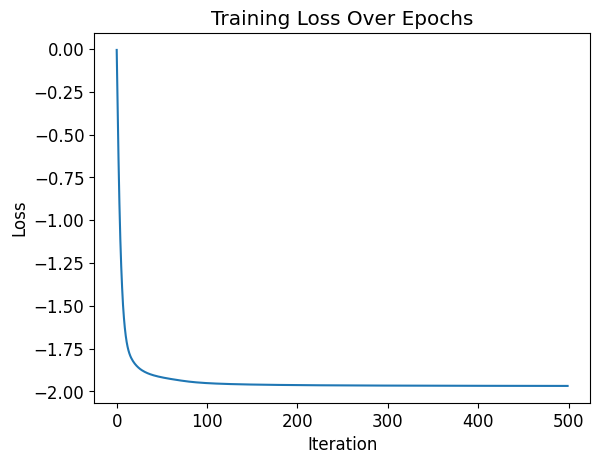

In [50]:
import sim_tangram.train_tangram as tg_cca
import torch

# tangram
tangram_sim, _ = tg_cca.read_csv_and_run_tangram(
    [torch.tensor(latent_sc, device='cuda:0', dtype=torch.float32)],
    [torch.tensor(latent_st, device='cuda:0', dtype=torch.float32)],
    num_epochs=500,
    print_interval=500,
    lambda_g1=1,
    lambda_g2=1,
)

**************************************************
S: torch.Size([1000, 100, 1])
G: torch.Size([1000, 100, 1])


100%|██████████| 500/500 [00:00<00:00, 2372.56it/s]

Epoch 500: Loss -1.9484333992004395
[[ 8.980247   -0.9460534  -0.71843624 ... -1.3044051  -0.8889296
   3.070225  ]
 [-2.4596338   8.474329   -1.9040997  ...  0.32899913  5.809647
  -0.5205966 ]
 [ 0.71042264 -1.6429069   8.798924   ...  1.2609041  -0.6702786
  -1.1654828 ]
 ...
 [-1.5308965   1.0883249  -3.6520605  ...  8.330671   -1.5353581
  -1.0523484 ]
 [-3.5249622  -1.9666859   0.28905246 ... -0.95230055  8.818569
   0.9519819 ]
 [-0.11759608 -1.2363725  -0.7963605  ... -1.2255191  -0.6028449
   8.783615  ]]


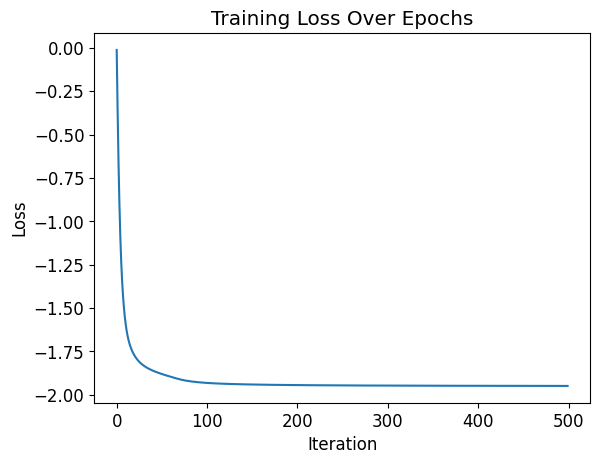

In [51]:
# 用cosine_similarity驱动的tangram进行计算
import cos_tg.train_tangram as tg_cos

# tangram
cos_sim_tg, _ = tg_cos.read_csv_and_run_tangram(
    [torch.tensor(latent_sc, device='cuda:0', dtype=torch.float32)],
    [torch.tensor(latent_st, device='cuda:0', dtype=torch.float32)],
    num_epochs=500,
    print_interval=500,
    lambda_g1=1,
    lambda_g2=1,
)

In [52]:
# 计算cosine_similarity
from sklearn.metrics.pairwise import cosine_similarity
cos = cosine_similarity(latent_sc, latent_st)
cos_mapping = cos.argmax(axis=1)
for i in range(len(cos_mapping)):
    if i < 30:
        if i % 5 == 0:
            print()
        print(f"{i:2d}: {cos_mapping[i]:4d}", end="\t")
print()
print('*'*50)

# 检验cosine_similarity驱动的tangram
cos_tg_mapping = cos_sim_tg.argmax(axis=1)
for i in range(len(cos_tg_mapping)):
    if i < 30:
        if i % 5 == 0:
            print()
        print(f"{i:2d}: {cos_tg_mapping[i]:4d}", end="\t")
print()
print('*'*50)

# 检验CCA驱动的tangram
tangram_mapping = tangram_sim.argmax(axis=1)
for i in range(len(tangram_mapping)):
    if i < 30:
        if i % 5 == 0:
            print()
        print(f"{i:2d}: {tangram_mapping[i]:4d}", end="\t")
print()
print('*'*50)



 0:    0	 1:    1	 2:    2	 3:    3	 4:    4	
 5:    5	 6:    6	 7:    7	 8:    8	 9:    9	
10:   10	11:   11	12:   12	13:   13	14:   14	
15:   15	16:   16	17:   17	18:   18	19:   19	
20:   20	21:   21	22:   22	23:   23	24:   24	
25:   25	26:   26	27:   27	28:   28	29:   29	
**************************************************

 0:    0	 1:    1	 2:    2	 3:    3	 4:    4	
 5:    5	 6:    6	 7:    7	 8:    8	 9:    9	
10:   10	11:   11	12:   12	13:   13	14:   14	
15:   15	16:   16	17:   17	18:   18	19:   19	
20:   20	21:   21	22:   22	23:   23	24:   24	
25:   25	26:   26	27:   27	28:   28	29:   29	
**************************************************

 0:    0	 1:    1	 2:    2	 3:    3	 4:    4	
 5:    5	 6:    6	 7:    7	 8:    8	 9:    9	
10:   10	11:   11	12:   12	13:   13	14:   14	
15:   15	16:   16	17:   17	18:   18	19:   19	
20:   20	21:   21	22:   22	23:   23	24:   24	
25:   25	26:   26	27:   27	28:   28	29:   29	
**************************************************


In [53]:
# 计算acc
gt = np.array(range(sample_size))
cos_acc = np.sum(cos_mapping == gt) / sample_size
tangram_acc = np.sum(tangram_mapping == gt) / sample_size
cos_tg_acc = np.sum(cos_tg_mapping == gt) / sample_size
print("cos accuracy:", cos_acc)
print("tangram accuracy:", tangram_acc)
print("cos_tg accuracy:", cos_tg_acc)


cos accuracy: 1.0
tangram accuracy: 1.0
cos_tg accuracy: 1.0


**************************************************
S: torch.Size([1000, 500, 1])
G: torch.Size([1000, 500, 1])


100%|██████████| 500/500 [00:00<00:00, 2201.37it/s]

Epoch 500: Loss -1.576133131980896
[[-3.427724   -2.2407382  -2.9739802  ... -2.4280648  -1.5989598
  -0.24781683]
 [-1.7737839   0.92557657 -3.1624355  ... -1.7075816  -2.5358627
   0.11985706]
 [-0.16192734 -2.8576992   0.49581128 ... -1.7264895  -2.8424497
  -0.87240803]
 ...
 [-0.76762843  4.973573   -1.1273601  ...  3.8383765   0.66610664
   4.3035736 ]
 [-3.0777457  -0.8203416  -3.1850266  ... -2.3993895  -3.4814408
  -1.5904565 ]
 [-1.5658939  -2.7886164  -2.3740895  ... -3.4781063  -2.6078787
  -0.73291355]]


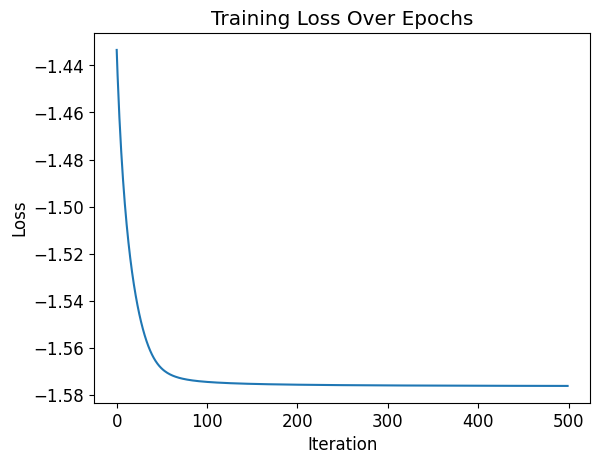

In [54]:
# 用cosine_similarity驱动的tangram进行计算
import cos_tg.train_tangram as tg_cos

# tangram
org_mapping, _ = tg_cos.read_csv_and_run_tangram(
    [torch.tensor(data_a, device='cuda:0', dtype=torch.float32)],
    [torch.tensor(data_b, device='cuda:0', dtype=torch.float32)],
    num_epochs=500,
    print_interval=500,
    lambda_g1=1,
    lambda_g2=1,
)

In [55]:
# 检验cosine_similarity驱动的tangram
cos_tg_mapping = org_mapping.argmax(axis=1)
for i in range(len(cos_tg_mapping)):
    if i < 30:
        if i % 5 == 0:
            print()
        print(f"{i:2d}: {cos_tg_mapping[i]:4d}", end="\t")
print()
print('*'*50)
cos_tg_acc = np.sum(cos_tg_mapping == gt) / sample_size
print("cos_tg accuracy:", cos_tg_acc)


 0:  876	 1:  588	 2:  340	 3:  913	 4:  363	
 5:  474	 6:  991	 7:  231	 8:  688	 9:   57	
10:  913	11:  263	12:  108	13:  826	14:  458	
15:  299	16:  414	17:  788	18:  871	19:  403	
20:  992	21:  869	22:  326	23:  152	24:  926	
25:  826	26:  868	27:  259	28:  894	29:  435	
**************************************************
cos_tg accuracy: 0.0
